# 03 – Correlation Analysis: SAR / Sentinel-2 vs LiDAR Structural Metrics

Reproduces Section 4.3 and Figures 8–10:
- Sample the structural metrics raster at regular 60 m grid (every 3rd pixel)
- Extract co-located SAR and Sentinel-2 composite values
- Compute Spearman rank correlations (Section 4.3, Figure 8)
- Generate correlation heatmaps and scatter plots

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
from src import config
from src.lidar_metrics import METRIC_NAMES
import numpy as np
import pandas as pd
import xarray as xr
import rasterio
from rasterio.transform import rowcol
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import geopandas as gpd
from shapely.geometry import Point

## 3.1 Sample structural metrics at regular 60 m grid

In [2]:
with rasterio.open(config.METRICS_RASTER) as src:
    transform = src.transform
    crs_lidar = src.crs
    all_bands = {src.descriptions[i]: src.read(i + 1) for i in range(src.count)}

height, width = next(iter(all_bands.values())).shape
stride = config.SAMPLE_STRIDE

# Regular pixel grid (every 3rd pixel in both directions, Section 4.2)
row_idx, col_idx = np.meshgrid(
    np.arange(0, height, stride),
    np.arange(0, width, stride),
    indexing='ij',
)
row_flat = row_idx.ravel()
col_flat = col_idx.ravel()

# Convert to map coordinates
xs, ys = rasterio.transform.xy(transform, row_flat, col_flat)
xs, ys = np.array(xs), np.array(ys)

# Apply random jitter (Section 4.2)
rng = np.random.default_rng(42)
jitter_m = config.SAMPLE_JITTER_MAX
xs += rng.uniform(-jitter_m, jitter_m, size=len(xs))
ys += rng.uniform(-jitter_m, jitter_m, size=len(ys))

# Read metric values at sample locations
rows_j, cols_j = rowcol(transform, xs, ys)
rows_j = np.clip(rows_j, 0, height - 1)
cols_j = np.clip(cols_j, 0, width - 1)

sample_data = {m: all_bands[m][rows_j, cols_j] for m in METRIC_NAMES if m in all_bands}
df = pd.DataFrame(sample_data)
df['x'] = xs
df['y'] = ys

# Drop pixels where any structural metric is NaN
df = df.dropna(subset=METRIC_NAMES[:3]).reset_index(drop=True)
print(f"Sample size: {len(df):,} pixels")

Sample size: 289 pixels


## 3.2 Extract co-located SAR and Sentinel-2 values

In [3]:
# sar_all = xr.open_zarr(config.SAR_ZARR)
# s2_all = xr.open_zarr(config.S2_ZARR)

sar_all = xr.open_dataset(config.SAR_NC)
s2_all = xr.open_dataset(config.S2_NC)

# Use dry-season composites for the main correlation analysis (Section 4.3)
sar_dry = sar_all.sel(period='dryseason')
s2_dry = s2_all.sel(period='dryseason')

# x/y coordinates are in TARGET_CRS (EPSG:3577)
# Reproject sample points from LiDAR CRS → EPSG:3577 if different
from pyproj import Transformer
if str(crs_lidar) != config.TARGET_CRS:
    trans = Transformer.from_crs(str(crs_lidar), config.TARGET_CRS, always_xy=True)
    xs_t, ys_t = trans.transform(xs, ys)
else:
    xs_t, ys_t = xs, ys

# Sample SAR bands at point locations
for var in ['VV_db', 'VH_db', 'VVVH_ratio_db']:
    df[f'SAR_{var}'] = sar_dry[var].sel(
        x=xr.DataArray(xs_t, dims='points'),
        y=xr.DataArray(ys_t, dims='points'),
        method='nearest',
    ).values

# Sample all S2 bands
s2_bands = config.S2_BANDS
for band in s2_bands:
    short = band.replace('nbart_', 's2_')
    df[short] = s2_dry[band].sel(
        x=xr.DataArray(xs_t, dims='points'),
        y=xr.DataArray(ys_t, dims='points'),
        method='nearest',
    ).values

df = df.dropna().reset_index(drop=True)
print(f"Final sample size after co-location: {len(df):,}")
df.to_parquet(config.TRAINING_TABLE)
print(f"Training table saved to {config.TRAINING_TABLE}")

Final sample size after co-location: 289
Training table saved to C:\Users\whusg\beetaloo_project\outputs\training_table.parquet


## 3.3 Spearman rank correlation matrix (Figure 8 equivalent)

In [4]:
remote_vars = (
    ['SAR_VV_db', 'SAR_VH_db', 'SAR_VVVH_ratio_db']
    + [f's2_{b.replace("nbart_", "")}' for b in s2_bands]
)
lidar_vars = METRIC_NAMES

rho_matrix = np.full((len(lidar_vars), len(remote_vars)), np.nan)
pval_matrix = np.full_like(rho_matrix, np.nan)

for i, lv in enumerate(lidar_vars):
    for j, rv in enumerate(remote_vars):
        valid = df[[lv, rv]].dropna()
        if len(valid) > 10:
            rho, p = stats.spearmanr(valid[lv], valid[rv])
            rho_matrix[i, j] = rho
            pval_matrix[i, j] = p

corr_df = pd.DataFrame(rho_matrix, index=lidar_vars, columns=remote_vars)
print("Spearman correlation matrix shape:", corr_df.shape)

Spearman correlation matrix shape: (23, 13)


C:\Users\whusg\AppData\Local\Temp\ipykernel_26028\1810924185.py:14: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = stats.spearmanr(valid[lv], valid[rv])
C:\Users\whusg\AppData\Local\Temp\ipykernel_26028\1810924185.py:14: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = stats.spearmanr(valid[lv], valid[rv])
C:\Users\whusg\AppData\Local\Temp\ipykernel_26028\1810924185.py:14: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = stats.spearmanr(valid[lv], valid[rv])
C:\Users\whusg\AppData\Local\Temp\ipykernel_26028\1810924185.py:14: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = stats.spearmanr(valid[lv], valid[rv])
C:\Users\whusg\AppData\Local\Temp\ipykernel_26028\1810924185.py:14: ConstantInputWarning: An input array is constant; the correlation coefficient is not def

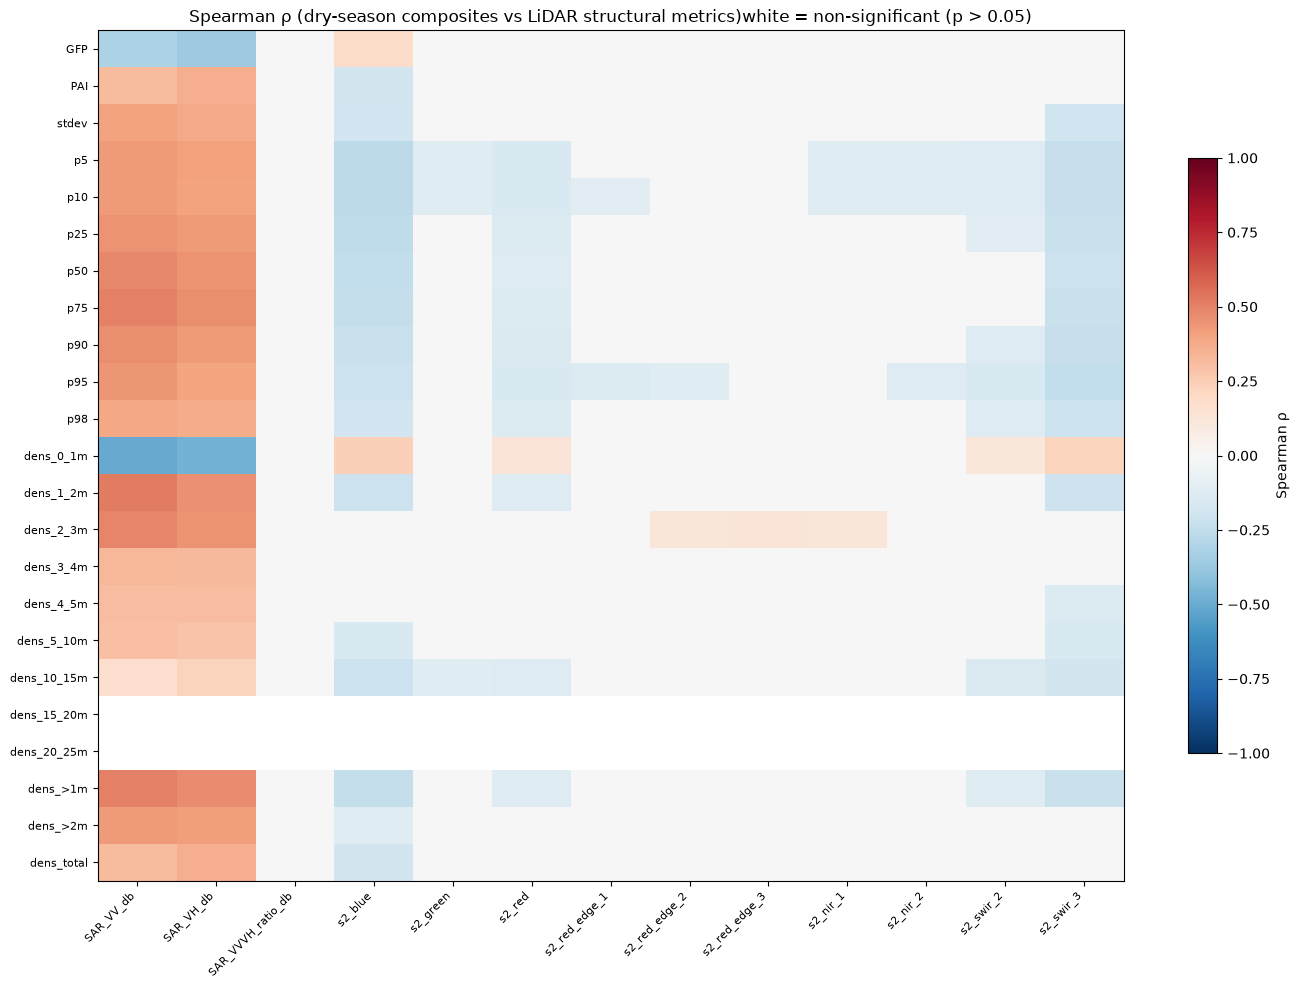

In [5]:
# Mask non-significant correlations (p > 0.05)
sig_mask = pval_matrix > 0.05
rho_plot = rho_matrix.copy()
rho_plot[sig_mask] = 0.0

fig, ax = plt.subplots(figsize=(14, 10))
im = ax.imshow(rho_plot, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(remote_vars)))
ax.set_xticklabels(remote_vars, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(lidar_vars)))
ax.set_yticklabels(lidar_vars, fontsize=8)
ax.set_title('Spearman ρ (dry-season composites vs LiDAR structural metrics)'
             'white = non-significant (p > 0.05)')
plt.colorbar(im, ax=ax, shrink=0.7, label='Spearman ρ')
plt.tight_layout()
plt.savefig(config.OUTPUT_DIR / 'fig_correlation_heatmap.png', dpi=150)
plt.show()

## 3.4 Top correlations: scatter plots (Figures 9–10 equivalent)

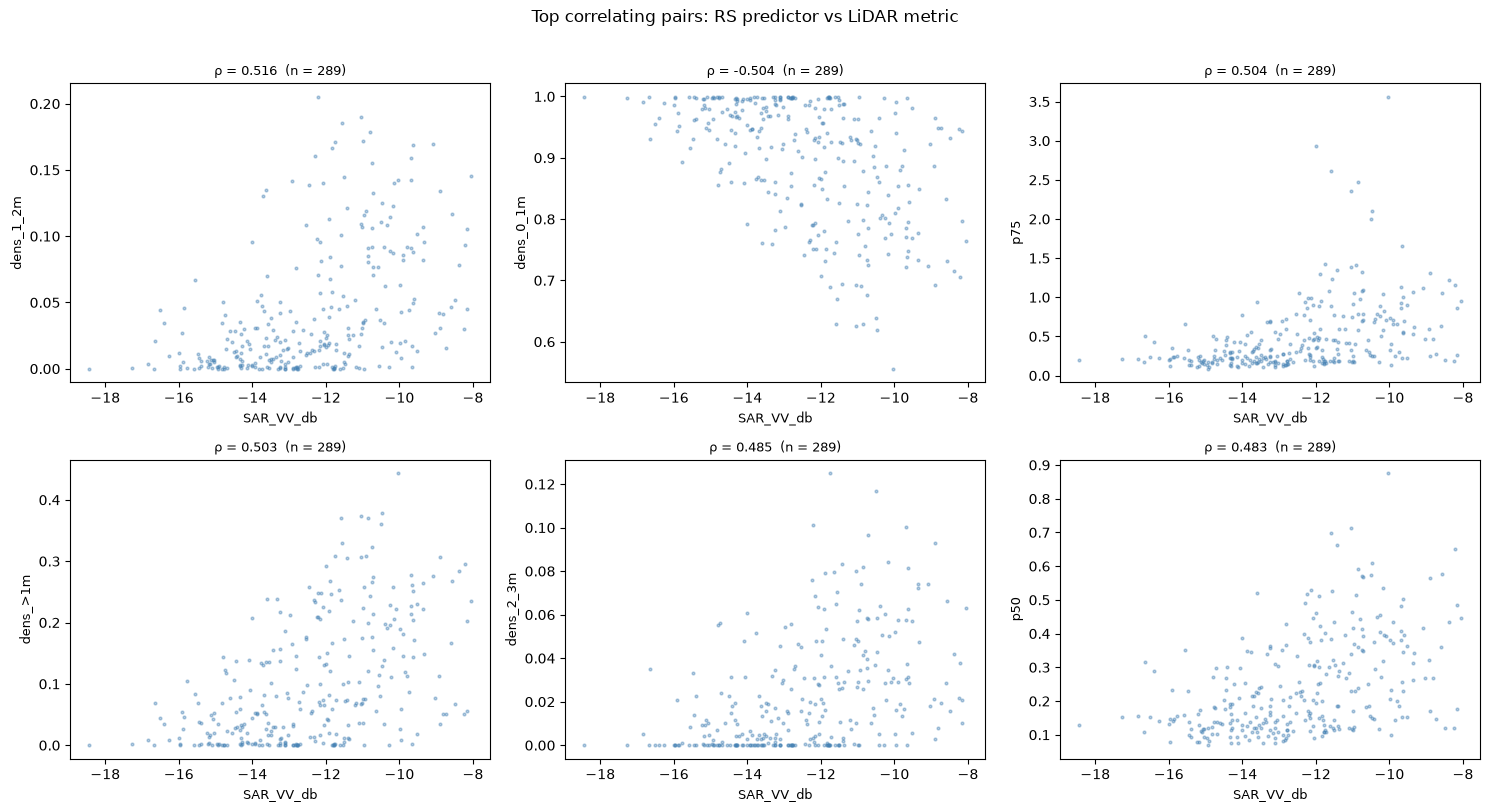

In [6]:
# Find top 6 (remote var, lidar var) pairs by |rho|
flat_idx = np.argsort(np.abs(rho_matrix[~np.isnan(rho_matrix)]).ravel())[::-1]
pairs = []
for i in range(len(lidar_vars)):
    for j in range(len(remote_vars)):
        if not np.isnan(rho_matrix[i, j]):
            pairs.append((abs(rho_matrix[i, j]), lidar_vars[i], remote_vars[j]))
pairs.sort(reverse=True)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (rho_abs, lv, rv) in zip(axes.ravel(), pairs[:6]):
    valid = df[[lv, rv]].dropna()
    rho, p = stats.spearmanr(valid[lv], valid[rv])
    ax.scatter(valid[rv], valid[lv], s=4, alpha=0.4, color='steelblue')
    ax.set_xlabel(rv, fontsize=9)
    ax.set_ylabel(lv, fontsize=9)
    ax.set_title(f'ρ = {rho:.3f}  (n = {len(valid):,})', fontsize=9)
plt.suptitle('Top correlating pairs: RS predictor vs LiDAR metric', y=1.01)
plt.tight_layout()
plt.savefig(config.OUTPUT_DIR / 'fig_top_scatter_pairs.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.5 Seasonal variability in SAR correlations

In [7]:
# Reproduce Section 4.3.1: compare correlations across seasonal composites
# (which season's SAR is most informative for predicting GFP and PAI?)
seasons = list(config.SEASONS.keys()) + ['dryseason', 'annual_' + str(int(config.DATE_START[:4]))]
target_metrics = ['GFP', 'PAI', 'stdev', 'p50']
sar_vars_short = ['VV_db', 'VH_db', 'VVVH_ratio_db']

season_rho = []
for period in list(config.SEASONS.keys()) + ['dryseason']:
    sar_period = sar_all.sel(period=period)
    for var in sar_vars_short:
        vals = sar_period[var].sel(
            x=xr.DataArray(xs_t, dims='p'), y=xr.DataArray(ys_t, dims='p'), method='nearest'
        ).values
        tmp = df.copy()
        tmp['rs_val'] = vals
        for lv in target_metrics:
            valid = tmp[[lv, 'rs_val']].dropna()
            if len(valid) > 10:
                rho, _ = stats.spearmanr(valid[lv], valid['rs_val'])
                season_rho.append({'period': period, 'sar_var': var, 'lidar_metric': lv, 'rho': rho})

season_df = pd.DataFrame(season_rho)
print(season_df.pivot_table(index='period', columns=['lidar_metric', 'sar_var'], values='rho').round(3).to_string())

lidar_metric    GFP                         PAI                         p50                       stdev                     
sar_var       VH_db VVVH_ratio_db  VV_db  VH_db VVVH_ratio_db  VV_db  VH_db VVVH_ratio_db  VV_db  VH_db VVVH_ratio_db  VV_db
period                                                                                                                      
autumn       -0.306        -0.021 -0.295  0.306         0.021  0.295  0.322         0.208  0.479  0.325         0.144  0.425
dryseason    -0.363         0.053 -0.317  0.363        -0.053  0.317  0.452         0.029  0.483  0.383         0.035  0.404
spring       -0.363         0.053 -0.317  0.363        -0.053  0.317  0.452         0.029  0.483  0.383         0.035  0.404
summer       -0.195        -0.136 -0.315  0.195         0.136  0.315  0.310         0.146  0.459  0.327         0.108  0.447
winter       -0.318        -0.039 -0.334  0.318         0.039  0.334  0.485         0.070  0.547  0.398         0.078  0.476
